# Core SAR Preprocessing Pipeline

This notebook implements the core preprocessing pipeline for the Sentinel-1 SAR oil spill detection dataset. The preprocessing steps include dataset inspection, class distribution analysis, grayscale image loading, pixel-range verification, Lee filtering, log transformation, percentile clipping, CLAHE contrast enhancement, resizing, 3-channel conversion, and saving the processed images for subsequent model training.

### Imports and Configuration

In [7]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

### Dataset Paths

In [15]:
# Main dataset path
# Change this path if the dataset is stored in a different location
DATASET_DIR = Path("data")

# Class folders
CLASS_0_DIR = DATASET_DIR / "S1SAR_UnBalanced_400by400_Class_0"
CLASS_1_DIR = DATASET_DIR / "S1SAR_UnBalanced_400by400_Class_1"

# Output folder for cleaned images


OUTPUT_DIR = Path("processed_dataset")

# Image extensions to search for
IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"]

# Fixed random seed for reproducibility
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Dataset directory:", DATASET_DIR)
print("Class 0 directory exists:", CLASS_0_DIR.exists())
print("Class 1 directory exists:", CLASS_1_DIR.exists())

Dataset directory: data
Class 0 directory exists: True
Class 1 directory exists: True


## 1. Dataset Loading and Image File Collection

The dataset folders are nested, so recursive search is used to collect image files from all subfolders. This step verifies that the dataset path and class folders are correctly loaded before preprocessing.

### Collect Image Files Recursively

In [16]:
def get_image_files(folder):
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(folder.rglob(ext))
    return sorted(image_files)

class_dirs = {
    "Class_0": CLASS_0_DIR,
    "Class_1": CLASS_1_DIR
}

class_files = {}

for class_name, folder in class_dirs.items():
    image_files = get_image_files(folder)
    class_files[class_name] = image_files

    print(f"{class_name}: {len(image_files)} images found")
    print("First 5 files:")
    for f in image_files[:5]:
        print(" -", f)
    print()

Class_0: 3725 images found
First 5 files:
 - data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_01RNDdyOUhULo97s_SFr_cls_0.jpg
 - data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_01UWcGmvMy3qNHgS_SFr_cls_0.jpg
 - data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0CugGbeejr96zxqr_SFr_cls_0.jpg
 - data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0EVoS7GsB3g8BDRK_GBR_cls_0.jpg
 - data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0ITOtZIqYb1GIpQT_GBR_cls_0.jpg

Class_1: 1905 images found
First 5 files:
 - data/S1SAR_UnBalanced_400by400_Class_1/1/0_0_0_img_0Omqba6y7AE0LCM3_JAV_cls_1.jpg
 - data/S1SAR_UnBalanced_400by400_Class_1/1/0_0_0_img_0bBRglmdLdC6cFxF_JAV_cls_1.jpg
 - data/S1SAR_UnBalanced_400by400_Class_1/1/0_0_0_img_0cKipkZKSSNVdT6P_JAV_cls_1.jpg
 - data/S1SAR_UnBalanced_400by400_Class_1/1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
 - data/S1SAR_UnBalanced_400by400_Class_1/1/0_0_0_img_11hRXUG2cQYhYoyy_GBR_cls_1.jpg



## 2. Class Distribution Check

The dataset is labeled as unbalanced, so the number of images in each class is checked. This is important because class imbalance can affect model training and may require class weighting or weighted sampling in the model stage.

### Plot Class Distribution

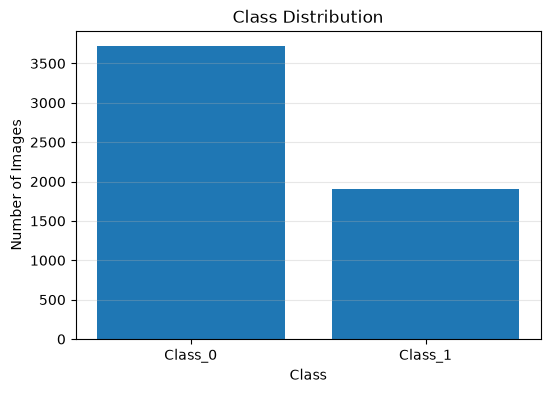

Class counts:
Class_0: 3725
Class_1: 1905


In [17]:
class_counts = {class_name: len(files) for class_name, files in class_files.items()}

plt.figure(figsize=(6, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Class counts:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

## 3. Image Loading and Format Verification

SAR images are loaded as grayscale images because Sentinel-1 SAR backscatter data is single-channel. This step verifies the image dimensions, data type, and pixel value range.

### Image Loading Function

In [18]:
def load_grayscale_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    return img

### Display Raw Sample Images

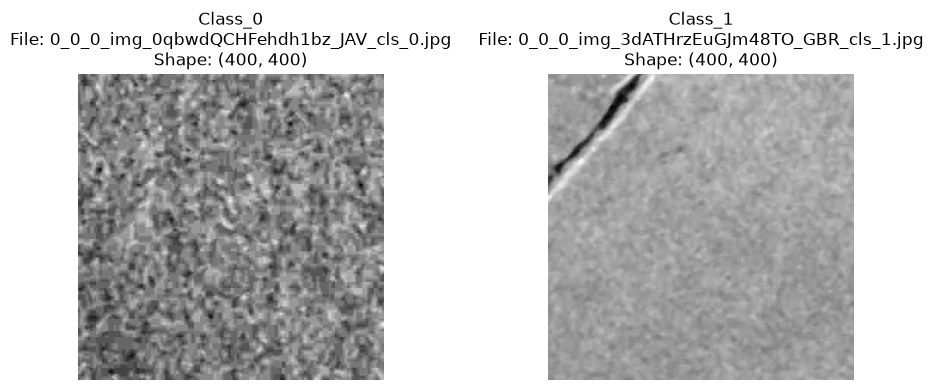

In [19]:
sample_index = 10

plt.figure(figsize=(10, 4))

for i, (class_name, files) in enumerate(class_files.items()):
    image_path = files[sample_index]
    img = load_grayscale_image(image_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{class_name}\nFile: {image_path.name}\nShape: {img.shape}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Pixel Range Inspection

In [20]:
for class_name, files in class_files.items():
    image_path = files[0]
    img = load_grayscale_image(image_path)

    print(f"{class_name}")
    print("File:", image_path.name)
    print("Shape:", img.shape)
    print("Data type:", img.dtype)
    print("Min pixel value:", img.min())
    print("Max pixel value:", img.max())
    print("Mean pixel value:", round(img.mean(), 2))
    print("Standard deviation:", round(img.std(), 2))
    print()

Class_0
File: 0_0_0_img_01RNDdyOUhULo97s_SFr_cls_0.jpg
Shape: (400, 400)
Data type: uint8
Min pixel value: 0
Max pixel value: 201
Mean pixel value: 113.67
Standard deviation: 31.91

Class_1
File: 0_0_0_img_0Omqba6y7AE0LCM3_JAV_cls_1.jpg
Shape: (400, 400)
Data type: uint8
Min pixel value: 55
Max pixel value: 100
Mean pixel value: 84.79
Standard deviation: 3.02



## 4. Pixel Intensity Histogram

Histograms are used to inspect the distribution of SAR pixel values. This helps show the original intensity range before applying log transformation, clipping, or contrast enhancement.

### Raw Image Histograms

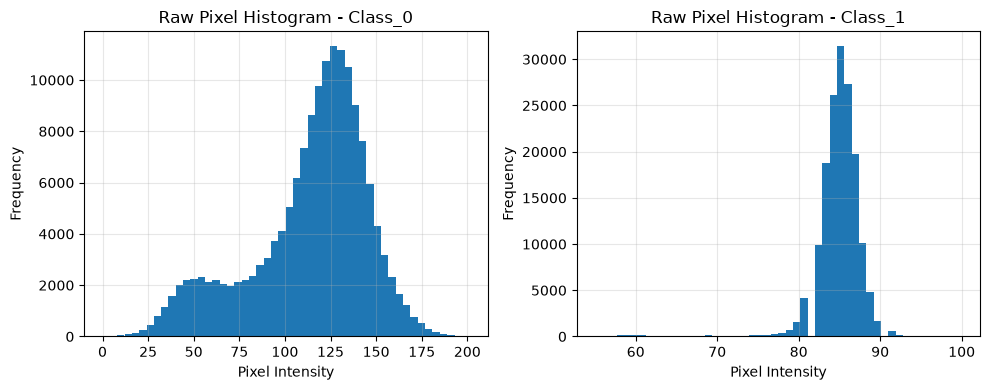

In [21]:
plt.figure(figsize=(10, 4))

for i, (class_name, files) in enumerate(class_files.items()):
    img = load_grayscale_image(files[0])

    plt.subplot(1, 2, i + 1)
    plt.hist(img.ravel(), bins=50)
    plt.title(f"Raw Pixel Histogram - {class_name}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

The dataset is split into training, validation, and test sets using a fixed random seed. The test set is kept untouched for final evaluation. A stratified split is used so that both classes are represented in each subset.

### Create Stratified Split

In [22]:
# Create file paths and labels
all_paths = []
all_labels = []

for class_name, files in class_files.items():
    label = 0 if class_name == "Class_0" else 1

    for file_path in files:
        all_paths.append(file_path)
        all_labels.append(label)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# First split: 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

# Second split: 15% validation, 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

print("\nTraining class counts:", np.bincount(train_labels))
print("Validation class counts:", np.bincount(val_labels))
print("Test class counts:", np.bincount(test_labels))

Training images: 3941
Validation images: 844
Test images: 845

Training class counts: [2607 1334]
Validation class counts: [559 285]
Test class counts: [559 286]


## 6. Lee Filtering for Speckle Noise Reduction

SAR images commonly contain speckle noise because of coherent radar imaging. Lee filtering is a spatial filtering method used to reduce speckle noise while preserving important image structures such as oil slick boundaries.

### Lee Filter Function

In [23]:
def lee_filter(img, window_size=5):
    """
    Apply Lee filter to reduce speckle noise in SAR images.

    Parameters:
        img: Grayscale input image.
        window_size: Local window size.

    Returns:
        Filtered image.
    """
    img = img.astype(np.float32)

    local_mean = cv2.blur(img, (window_size, window_size))
    local_mean_sq = cv2.blur(img ** 2, (window_size, window_size))
    local_variance = local_mean_sq - local_mean ** 2

    overall_variance = np.var(img)

    weights = local_variance / (local_variance + overall_variance + 1e-8)
    filtered = local_mean + weights * (img - local_mean)

    return np.clip(filtered, 0, 255).astype(np.uint8)

### Raw vs Lee-Filtered Example

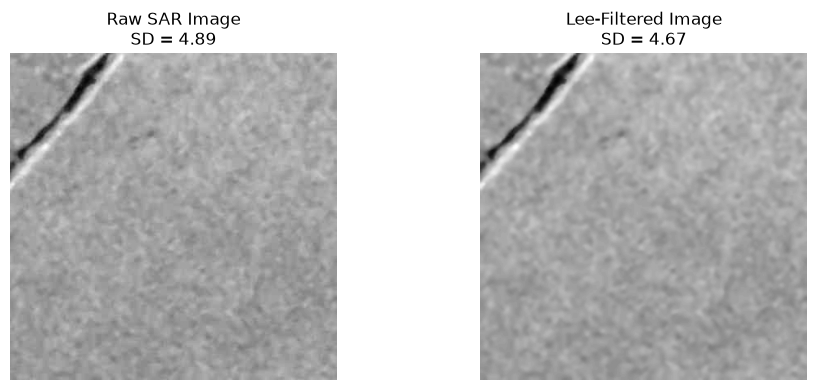

In [24]:
sample_path = class_files["Class_1"][10]
raw_img = load_grayscale_image(sample_path)
lee_img = lee_filter(raw_img, window_size=5)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(raw_img, cmap="gray")
plt.title(f"Raw SAR Image\nSD = {raw_img.std():.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lee_img, cmap="gray")
plt.title(f"Lee-Filtered Image\nSD = {lee_img.std():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

The standard deviation decreased from 4.89 to 4.67 after Lee filtering, indicating reduced speckle noise while preserving important image structures.

## 7. Log / dB Transformation for SAR Backscatter Scaling

SAR backscatter values can have a wide intensity range. A log or dB transformation compresses the intensity range and makes dark oil slick regions easier to compare with the surrounding sea surface. This step is connected to intensity transformations.

### Log/dB Transformation Function

In [25]:
def log_transform(img):
    """
    Apply log transformation to compress SAR intensity range.
    """
    img = img.astype(np.float32)
    log_img = np.log1p(img)

    # Normalize back to 0-255 for visualization and saving
    log_img = cv2.normalize(log_img, None, 0, 255, cv2.NORM_MINMAX)

    return log_img.astype(np.uint8)

### Raw vs Log/dB Transformed Example

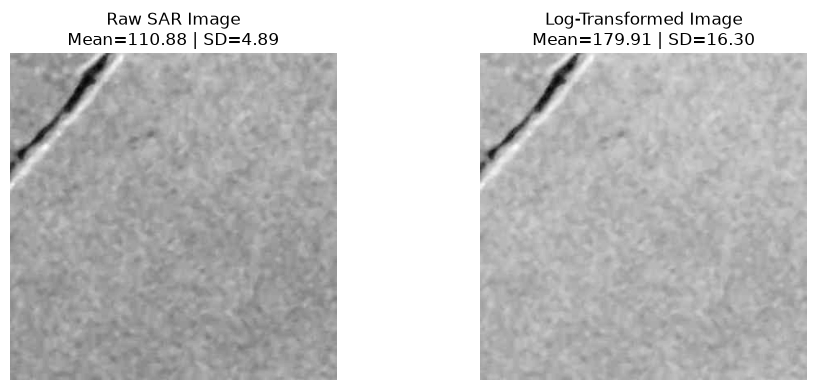

In [26]:
log_img = log_transform(raw_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(raw_img, cmap="gray")
plt.title( f"Raw SAR Image\nMean={raw_img.mean():.2f} | SD={raw_img.std():.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap="gray")
plt.title(f"Log-Transformed Image\nMean={log_img.mean():.2f} | SD={log_img.std():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

The increase in standard deviation from 4.89 to 16.30 indicates enhanced contrast after log transformation, making important image features more distinguishable.

## 8. Percentile Clipping for Contrast Enhancement

Percentile clipping removes extreme low and high pixel values. In SAR images, very bright scatterers such as ships or metal structures may create outliers. Clipping the 1st and 99th percentiles improves the useful contrast range before applying further enhancement.

### Percentile Clipping Function

In [27]:
def percentile_clipping(img, lower_percentile=1, upper_percentile=99):
    """
    Clip image intensities using lower and upper percentiles.
    """
    img = img.astype(np.float32)

    lower = np.percentile(img, lower_percentile)
    upper = np.percentile(img, upper_percentile)

    clipped = np.clip(img, lower, upper)
    clipped = cv2.normalize(clipped, None, 0, 255, cv2.NORM_MINMAX)

    return clipped.astype(np.uint8)

### Histogram Before and After Clipping

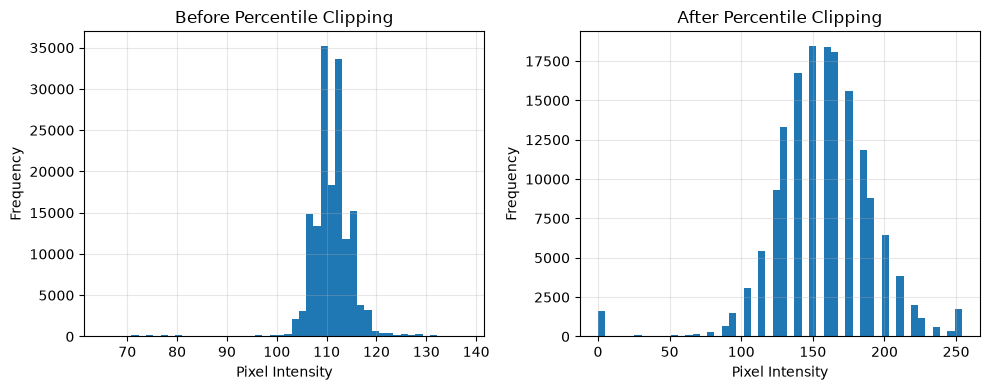

In [28]:
clipped_img = percentile_clipping(raw_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(raw_img.ravel(), bins=50)
plt.title("Before Percentile Clipping")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(clipped_img.ravel(), bins=50)
plt.title("After Percentile Clipping")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. CLAHE for Local Contrast Enhancement

Contrast Limited Adaptive Histogram Equalization, or CLAHE, enhances local contrast in grayscale SAR images. It is useful for highlighting dark oil slick regions while limiting noise over-amplification in homogeneous sea areas.

### CLAHE Function

In [29]:
def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to enhance local contrast.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    enhanced = clahe.apply(img)

    return enhanced

### Raw vs Contrast-Enhanced Example

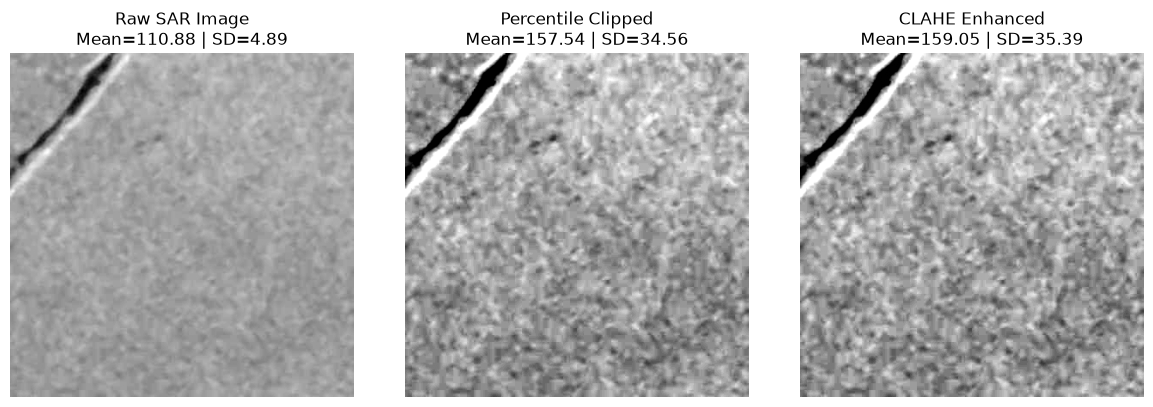

In [30]:
contrast_img = apply_clahe(clipped_img)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(raw_img, cmap="gray")
plt.title(f"Raw SAR Image\nMean={raw_img.mean():.2f} | SD={raw_img.std():.2f}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(clipped_img, cmap="gray")
plt.title( f"Percentile Clipped\nMean={clipped_img.mean():.2f} | SD={clipped_img.std():.2f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contrast_img, cmap="gray")
plt.title( f"CLAHE Enhanced\nMean={contrast_img.mean():.2f} | SD={contrast_img.std():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

The standard deviation increased from 4.89 to 34.56 after percentile clipping and further increased to 35.39 after CLAHE. This indicates enhanced contrast and improved visibility of important image structures.

## 10. Resize, Channel Formatting, and Normalization

The SAR images are resized to 224 × 224 pixels to match the expected input size of the pretrained deep learning models used in this project. Since SAR images are grayscale, the single channel is copied three times to create a 3-channel image. No color information is added; this is only done for compatibility with pretrained ImageNet models.

The image is then normalized using ImageNet mean and standard deviation values.

### Resize, 3-Channel Conversion, and Normalization

In [31]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def resize_and_make_3channel(img, size=(224, 224)):
    """
    Resize grayscale image and convert it to 3-channel format.
    """
    resized = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
    three_channel = np.stack([resized, resized, resized], axis=-1)

    return three_channel

def normalize_imagenet(img_3ch):
    """
    Normalize 3-channel image using ImageNet mean and standard deviation.
    Output is float32.
    """
    img = img_3ch.astype(np.float32) / 255.0
    normalized = (img - IMAGENET_MEAN) / IMAGENET_STD

    return normalized.astype(np.float32)

## 11. Complete Preprocessing Function

This function combines the full preprocessing pipeline: grayscale loading, Lee filtering, log transformation, percentile clipping, CLAHE, resizing, 3-channel conversion, and normalization. A separate visualization output is also created for saving as PNG images.

### Full Preprocessing Pipeline Function

In [32]:
def preprocess_image(image_path, apply_normalization=True):
    """
    Complete SAR preprocessing pipeline.

    Steps:
    1. Load grayscale image
    2. Apply Lee filtering
    3. Apply log transformation
    4. Apply percentile clipping
    5. Apply CLAHE
    6. Resize to 224x224
    7. Convert to 3 channels
    8. Normalize using ImageNet statistics if required

    Returns:
        processed_for_model: normalized 3-channel image for model input
        processed_for_saving: uint8 3-channel image for saving/visualization
    """
    img = load_grayscale_image(image_path)

    filtered = lee_filter(img, window_size=5)
    log_img = log_transform(filtered)
    clipped = percentile_clipping(log_img, lower_percentile=1, upper_percentile=99)
    enhanced = apply_clahe(clipped)

    processed_3ch = resize_and_make_3channel(enhanced, size=(224, 224))

    if apply_normalization:
        processed_for_model = normalize_imagenet(processed_3ch)
    else:
        processed_for_model = processed_3ch.astype(np.float32) / 255.0

    processed_for_saving = processed_3ch.astype(np.uint8)

    return processed_for_model, processed_for_saving

### Test the Full Pipeline on One Image

Original image shape: (400, 400)
Processed image for saving shape: (224, 224, 3)
Processed image for saving dtype: uint8
Processed image for model shape: (224, 224, 3)
Processed image for model dtype: float32
Processed image for model min: -2.0836544
Processed image for model max: 2.6225708


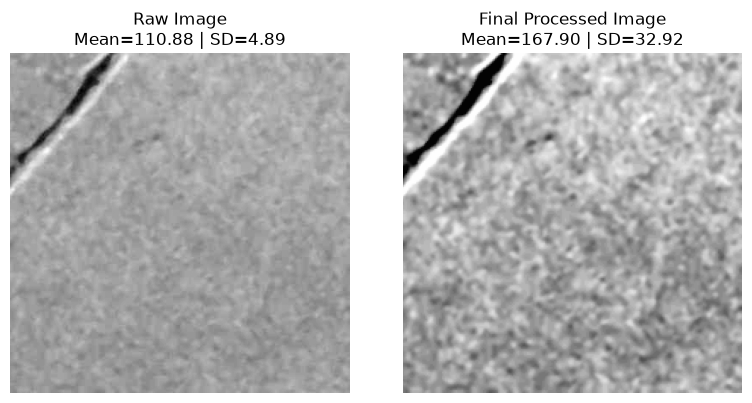

In [33]:
processed_model, processed_save = preprocess_image(sample_path)

print("Original image shape:", raw_img.shape)
print("Processed image for saving shape:", processed_save.shape)
print("Processed image for saving dtype:", processed_save.dtype)
print("Processed image for model shape:", processed_model.shape)
print("Processed image for model dtype:", processed_model.dtype)
print("Processed image for model min:", processed_model.min())
print("Processed image for model max:", processed_model.max())

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(raw_img, cmap="gray")
plt.title( f"Raw Image\nMean={raw_img.mean():.2f} | SD={raw_img.std():.2f}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_save)
plt.title(f"Final Processed Image\nMean={processed_save.mean():.2f} | SD={processed_save.std():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

After applying the complete preprocessing pipeline, the standard deviation increased from 4.89 to 32.92, indicating a substantial enhancement in image contrast and feature visibility. This makes important SAR structures more distinguishable for subsequent model training.

## 12. Save Cleaned Processed Images

The processed images are saved into train, validation, and test folders. The original dataset is not overwritten. These cleaned images can be used by the model training stage.

### Save Processed Dataset

In [34]:
def save_processed_split(paths, labels, split_name):
    """
    Save processed images into split/class folders.
    """
    for image_path, label in zip(paths, labels):
        class_folder = "Class_0" if label == 0 else "Class_1"

        output_folder = OUTPUT_DIR / split_name / class_folder
        output_folder.mkdir(parents=True, exist_ok=True)

        _, processed_save = preprocess_image(image_path)

        output_filename = image_path.stem + ".png"
        output_path = output_folder / output_filename

        cv2.imwrite(str(output_path), cv2.cvtColor(processed_save, cv2.COLOR_RGB2BGR))

    print(f"{split_name} processed images saved successfully.")

### Run Saving Process

In [35]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

save_processed_split(train_paths, train_labels, "train")
save_processed_split(val_paths, val_labels, "val")
save_processed_split(test_paths, test_labels, "test")

print("All processed images saved in:", OUTPUT_DIR)

train processed images saved successfully.
val processed images saved successfully.
test processed images saved successfully.
All processed images saved in: processed_dataset


### Verify Saved Processed Dataset

In [36]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for class_name in ["Class_0", "Class_1"]:
        folder = OUTPUT_DIR / split / class_name
        files = list(folder.glob("*.png"))

        print(f"{class_name}: {len(files)} images")


TRAIN
Class_0: 2607 images
Class_1: 1334 images

VAL
Class_0: 559 images
Class_1: 285 images

TEST
Class_0: 559 images
Class_1: 286 images


### Processed Dataset Verification

The processed dataset was successfully saved into train, validation, and test folders. The split follows the required 70/15/15 structure while preserving both classes in each subset.

The dataset is imbalanced. Class_0 contains 3725 images in total, while Class_1 contains 1905 images in total. This imbalance should be considered during model training using class-weighted loss or weighted sampling.

## 13. Summary of Preprocessing Steps

The core SAR preprocessing pipeline prepared the Sentinel-1 SAR images for later analysis and model training. First, the dataset structure was checked, and the image files were collected recursively because the class folders contained nested subfolders. The class distribution was also inspected, showing that the dataset is imbalanced, with Class_0 containing more images than Class_1.

Each SAR image was loaded as a grayscale image and its format, shape, data type, and pixel intensity range were verified. The original images had a size of 400 × 400 pixels. Lee filtering was then applied to reduce speckle noise, which is common in SAR images, while preserving important boundaries and texture details. This step is connected to spatial filtering and image restoration.

After denoising, a log transformation was applied to compress the SAR backscatter intensity range. Percentile clipping was used to reduce the effect of extreme pixel values, and CLAHE was applied to enhance local contrast. These steps are related to intensity transformations because they improve the visibility of dark oil slick regions against the surrounding sea surface.

Finally, the processed images were resized to 224 × 224 pixels, converted into three identical channels, normalized using ImageNet statistics for compatibility with pretrained models, and saved into the train, validation, and test folders.

----

---

## Exploratory Analysis section

In this section, we perform an exploratory analysis on the preprocessed Sentinel-1 SAR images to understanding the visual and structural info of the dataset. The analysis covers three main techniques:  
1. FFT spectrum analysis 
2. Edge detection using Sobel and Canny 
3. Morphological operations


Loading processed data

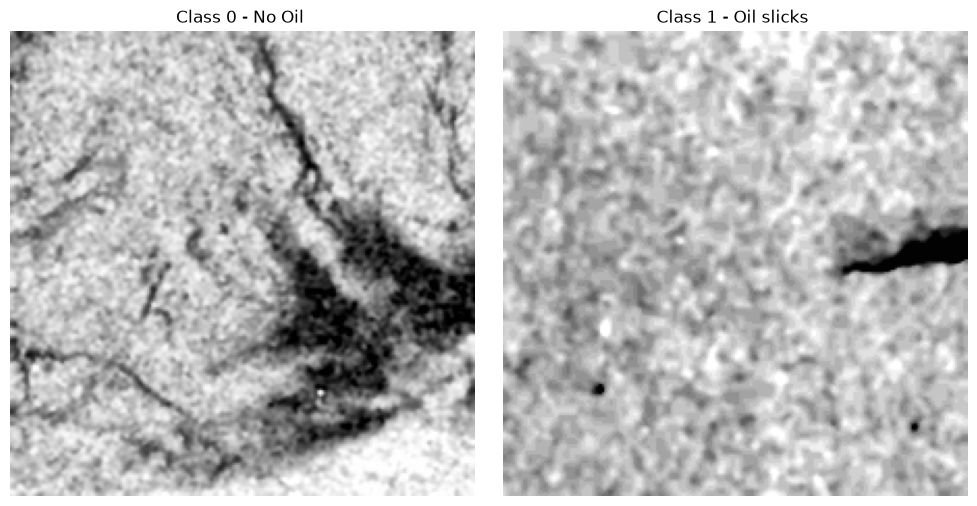

In [37]:
class0_files = sorted((OUTPUT_DIR / "train" / "Class_0").glob("*.png"))
class1_files = sorted((OUTPUT_DIR / "train" / "Class_1").glob("*.png"))

ProcessedImg0 = cv2.imread(str(class0_files[0]), cv2.IMREAD_GRAYSCALE)
ProcessedImg1 = cv2.imread(str(class1_files[0]), cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ProcessedImg0, cmap='gray')
plt.title("Class 0 - No Oil ")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ProcessedImg1, cmap='gray')
plt.title("Class 1 - Oil slicks ")
plt.axis("off")

plt.tight_layout()
plt.show()

# FFT Spectrum examples

- Here we applied FFT on one sample from each class to inspect the frequency domain of the preprocessed SAR images

In [38]:
def fft_analysis(img, title):
    F = np.fft.fft2(img) 
    F_shifted = np.fft.fftshift(F)
    shifted_magnitude = np.abs(F_shifted)
    log_shifted_magnitude = np.log(1 + shifted_magnitude)
    phase = np.angle(F_shifted)
    
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(log_shifted_magnitude, cmap='gray')
    plt.title('Shifted Log Magnitude Spectrum')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(phase, cmap='gray')
    plt.title('Phase Spectrum')
    plt.axis('off')
    


    plt.suptitle(f"FFT Spectrum Analysis - {title}")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

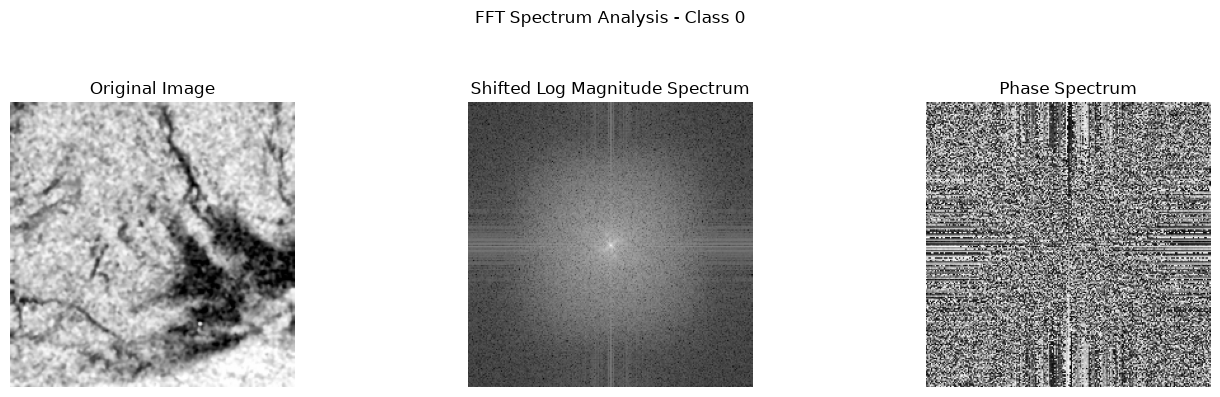

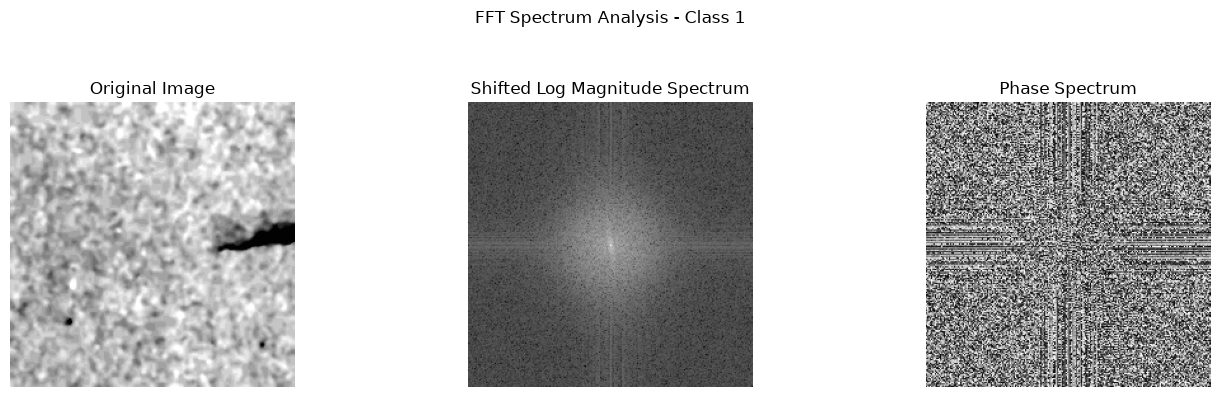

In [39]:
fft_analysis(ProcessedImg0, "Class 0")
fft_analysis(ProcessedImg1, "Class 1")

- Here we shows importance of the Magnitude vs phase, what happen when we remove the phase and keep only the magnitude, and when we remove the magnitude and keep only the phase


In [40]:
def fft_reconstruction(img, title):
    F = np.fft.fft2(img.astype(np.float32))
    
    mag_only         = np.abs(F) * np.exp(1j * 0)
    phase_only       = np.exp(1j * np.angle(F))

    recon_mag   = np.fft.ifft2(mag_only).real
    recon_phase = np.fft.ifft2(phase_only).real

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(recon_mag, cmap='gray')
    plt.title('Reconstruction from Magnitude Only')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(recon_phase, cmap='gray')
    plt.title('Reconstruction from Phase Only')
    plt.axis('off')

    plt.suptitle(f"FFT Magnitude vs Phase Reconstruction - {title}")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

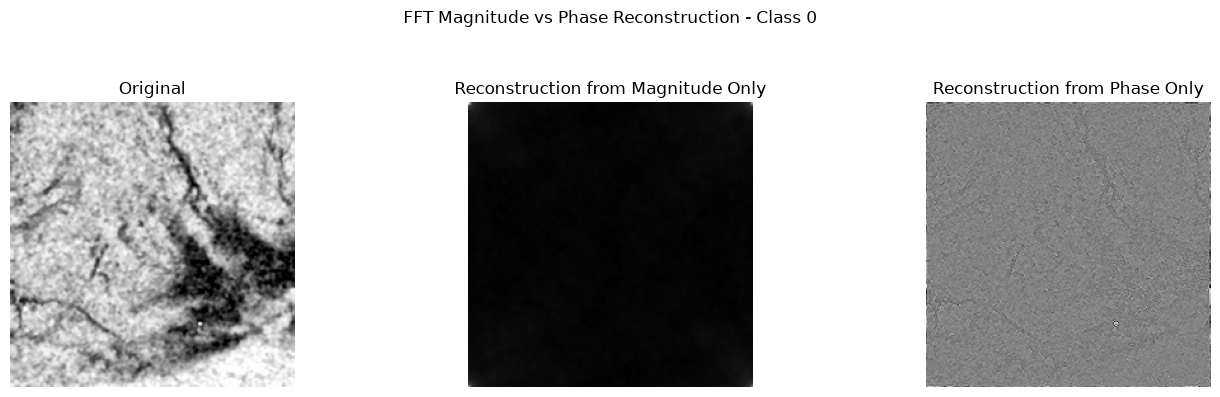

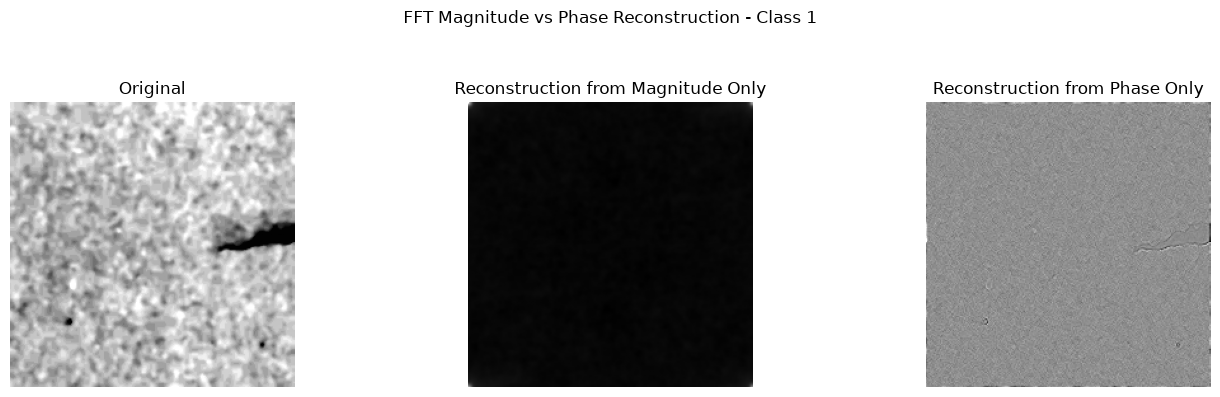

In [41]:
fft_reconstruction(ProcessedImg0, "Class 0")
fft_reconstruction(ProcessedImg1, "Class 1")

- Here we applies a Laplacian filter in the frequency domain to highlight edges and sharp changes in the images.

In [42]:
def fft_laplacian(img, title):
    M, N = img.shape
    u = np.fft.fftfreq(M).reshape(-1, 1)
    v = np.fft.fftfreq(N).reshape(1, -1)
    
    laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)
    
    F = np.fft.fft2(img.astype(np.float32))
    F_lap = F * laplacian_filter
    
    laplacian_img = np.fft.ifft2(F_lap).real

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(np.log(1 + np.abs(np.fft.fftshift(F_lap))), cmap='gray')
    plt.title('Laplacian Spectrum')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(laplacian_img, cmap='gray')
    plt.title('Laplacian Output')
    plt.axis('off')

    plt.suptitle(f"Laplacian in the frequency domain - {title}")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

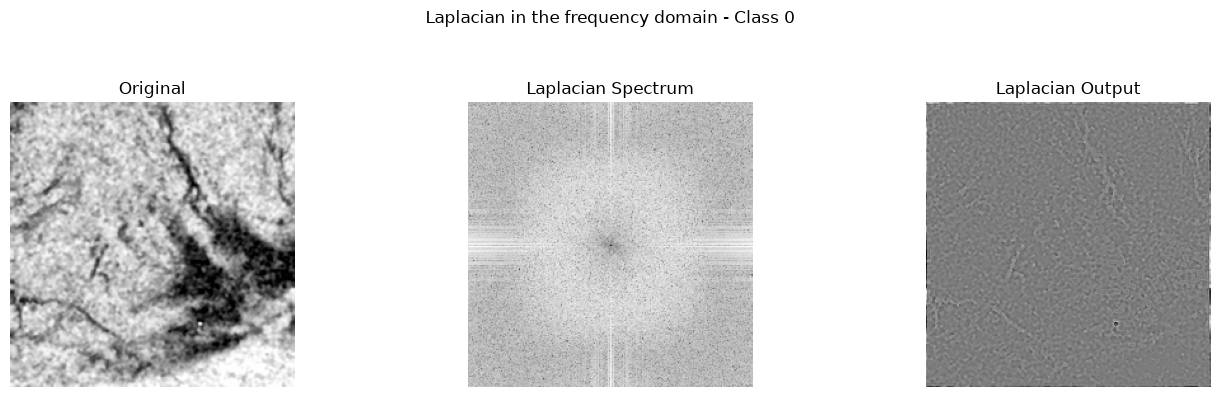

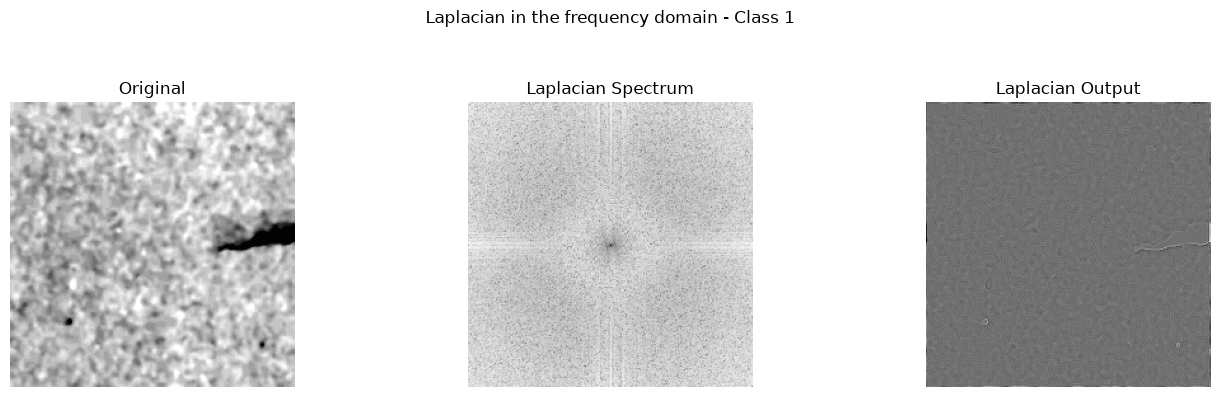

In [43]:
fft_laplacian(ProcessedImg0, "Class 0")
fft_laplacian(ProcessedImg1, "Class 1")

# Sobel & Canny (edge detection)

- Here we applied sobel and canny edge detection to visualize the intensity gradientsin the preprocessed images
- Sobel detects edges by computing the gradient magnitude in both horizontal and vertical directions using a 3x3 kernel
- Canny detects edges using double thresholding with a low threshold of 100 and a high threshold of 200.

In [44]:
def edge_analysis(name, img):
    img = img.astype(np.uint8)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    sobel = cv2.magnitude(sobelx, sobely)
    sobel = np.uint8(255 * (sobel / np.max(sobel + 1e-8)))

    canny = cv2.Canny(img, 100, 200)

    plt.figure(figsize=(14,6))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel Edges")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny Edges")
    plt.axis("off")
    
    plt.suptitle(f"Edge Detection - {name}")
    plt.tight_layout()
    plt.show()

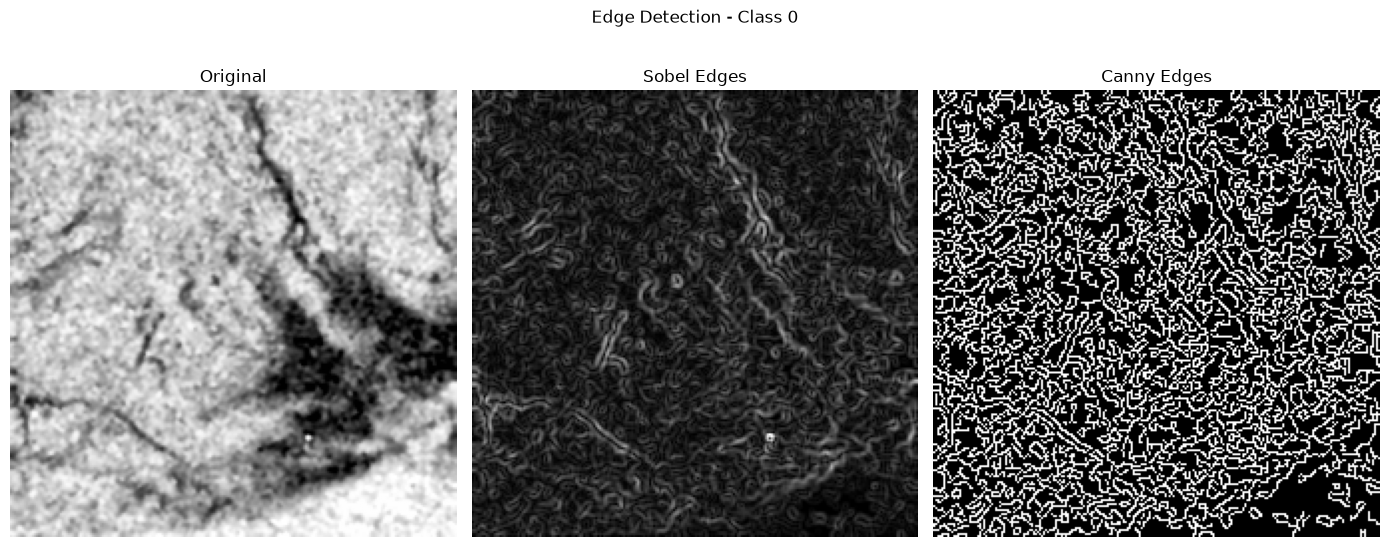

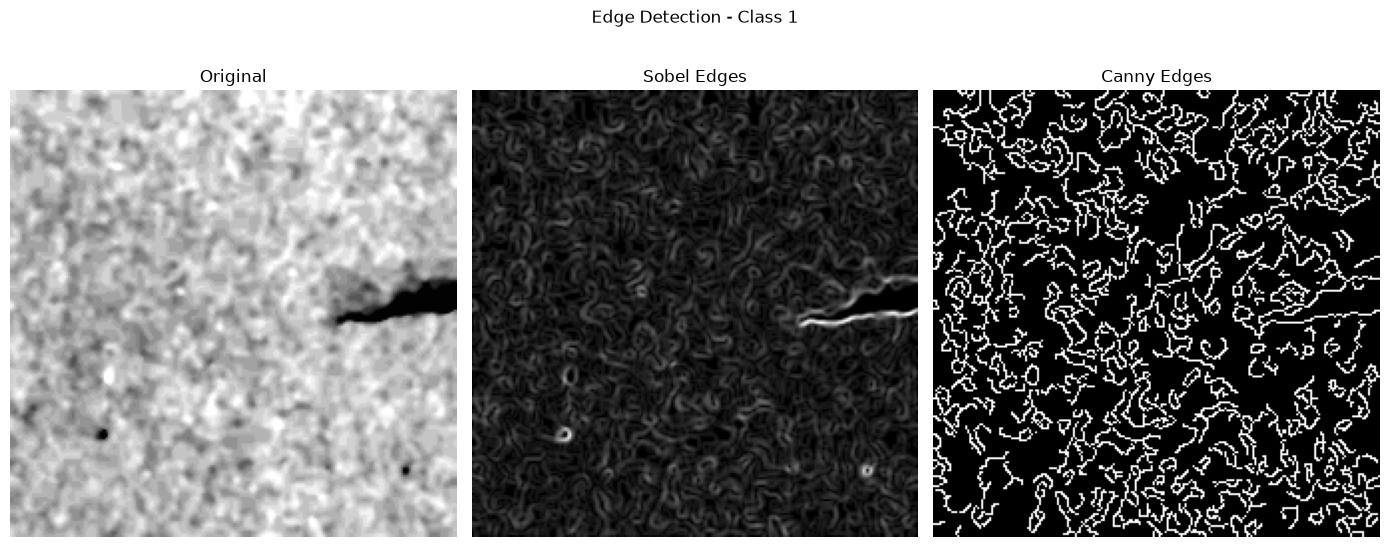

In [45]:
edge_analysis("Class 0", ProcessedImg0)
edge_analysis("Class 1", ProcessedImg1)

# Morphological Operations

- We applied thresholding followed by 4 morphological operations on one sample from each class using a 3x3 kernel. Opening to removes small noises in image and closing to filling small holes and gaps. Also we apply Erosion to shrink the bright regions, and dilation to expand the bright regions 

In [46]:
def morphology_analysis(name, img):

    kernel = np.ones((3,3), np.uint8)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    erosion = cv2.erode(thresh, kernel, iterations=1)
    dilation = cv2.dilate(thresh, kernel, iterations=1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,6,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,6,2) # Threshold 
    plt.imshow(thresh, cmap='gray')
    plt.title("Otsu Threshold")
    plt.axis("off")


    plt.subplot(1,6,3)
    plt.imshow(opening, cmap='gray')
    plt.title("Opening")
    plt.axis("off")

    plt.subplot(1,6,4)
    plt.imshow(closing, cmap='gray')
    plt.title("Closing")
    plt.axis("off")

    plt.subplot(1,6,5)
    plt.imshow(erosion, cmap='gray')
    plt.title("Erosion")
    plt.axis("off")

    plt.subplot(1,6,6)
    plt.imshow(dilation, cmap='gray')
    plt.title("Dilation")
    plt.axis("off")

    plt.suptitle(f"Morphological Operations - {name}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

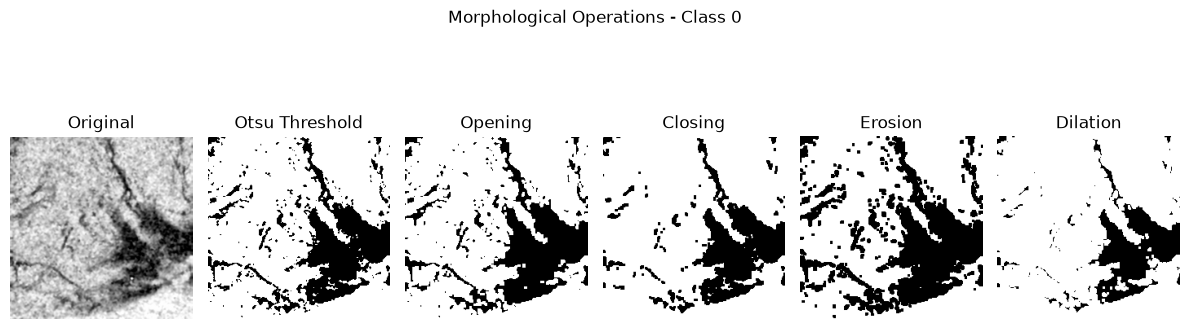

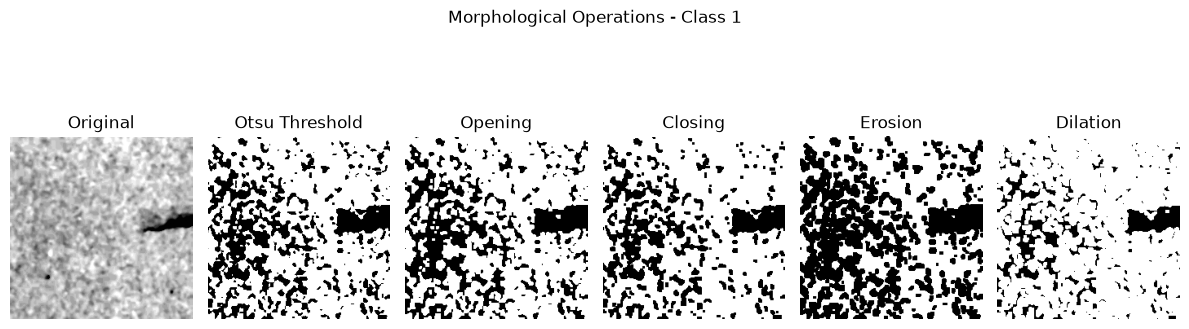

In [47]:
morphology_analysis("Class 0", ProcessedImg0)
morphology_analysis("Class 1", ProcessedImg1)